# Machine Learning Model Training

This notebook develops and evaluates machine learning models for wildfire burned-area prediction using the preprocessed Mesogeos wildfire dataset.

The workflow includes:

1. Loading the preprocessed training and testing datasets
2. Verifying feature consistency and data integrity
3. Establishing baseline models
4. Training and comparing multiple machine learning algorithms
5. Evaluating model performance using appropriate regression metrics
6. Investigating overfitting and generalisation performance
7. Hyperparameter tuning of selected models
8. Selecting the final predictive model
9. Evaluating the final model on the held-out test set
10. Saving the final model for integration into the prediction system

The target variable is the logarithmically transformed burned area:

`log(1 + burned_area_ha)`

The test set remains untouched during model development and hyperparameter tuning.

In [5]:
from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
# DEFINE PROJECT AND PROCESSED DATA PATHS

PROJECT_ROOT = Path.cwd().parents[1]

PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed"

print("Project root:")
print(PROJECT_ROOT)

print("\nProcessed data directory:")
print(PROCESSED_DIR)

Project root:
c:\Projects\ML Based Forest-Fire Prediction Project

Processed data directory:
c:\Projects\ML Based Forest-Fire Prediction Project\dataset\processed


In [7]:
# LOAD PROCESSED TRAINING AND TESTING DATA

X_train = pd.read_csv(PROCESSED_DIR / "X_train.csv")
X_test = pd.read_csv(PROCESSED_DIR / "X_test.csv")

y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv").squeeze("columns")

print("Processed datasets loaded successfully.")

print("\nX_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

Processed datasets loaded successfully.

X_train shape: (9042, 44)
X_test shape : (2261, 44)

y_train shape: (9042,)
y_test shape : (2261,)


In [5]:
# LOAD FEATURE LIST

with open(PROCESSED_DIR / "final_features.json", "r") as f:
    final_features = json.load(f)

print("Number of final features:", len(final_features))

print("\nFinal features:")
for i, feature in enumerate(final_features, start=1):
    print(f"{i:02d}. {feature}")

Number of final features: 44

Final features:
01. latitude
02. longitude
03. elevation
04. slope_degrees
05. aspect
06. curvature
07. roads_distance_km
08. population
09. temperature_c
10. dew_point_c
11. relative_humidity
12. wind_speed
13. rainfall_mm
14. surface_pressure
15. solar_radiation
16. soil_moisture
17. ndvi
18. lai
19. lc_agriculture
20. lc_forest
21. lc_grassland
22. lc_settlement
23. lc_shrubland
24. lc_sparse_vegetation
25. lc_water_bodies
26. lc_wetland
27. year
28. month
29. day_of_year
30. month_sin
31. month_cos
32. day_of_year_sin
33. day_of_year_cos
34. temperature_c_missing
35. dew_point_c_missing
36. relative_humidity_missing
37. wind_speed_missing
38. rainfall_mm_missing
39. surface_pressure_missing
40. solar_radiation_missing
41. soil_moisture_missing
42. wind_direction_missing
43. wind_direction_sin
44. wind_direction_cos


In [6]:
assert list(X_train.columns) == final_features
assert list(X_test.columns) == final_features

print("Training feature order verified.")
print("Testing feature order verified.")
print("Feature consistency check passed.")

Training feature order verified.
Testing feature order verified.
Feature consistency check passed.


In [7]:
# CHECK FOR REMAINING MISSING VALUES

train_missing = X_train.isna().sum().sum()
test_missing = X_test.isna().sum().sum()

print("Missing values in X_train:", train_missing)
print("Missing values in X_test :", test_missing)

assert train_missing == 0
assert test_missing == 0

print("\nMissing-value validation passed.")

Missing values in X_train: 0
Missing values in X_test : 0

Missing-value validation passed.


In [9]:
# VERIFY TARGET VARIABLE

print("Training target statistics:")
display(y_train.describe())

print("\nTesting target statistics:")
display(y_test.describe())

print("\nTarget data types:")
print("y_train:", y_train.dtype)
print("y_test :", y_test.dtype)

Training target statistics:


count    9042.000000
mean        5.132169
std         1.201892
min         3.433987
25%         4.204693
50%         4.890349
75%         5.834079
max        11.586204
Name: log_burned_area, dtype: float64


Testing target statistics:


count    2261.000000
mean        5.084775
std         1.188039
min         3.433987
25%         4.158883
50%         4.844187
75%         5.768321
max        10.046678
Name: log_burned_area, dtype: float64


Target data types:
y_train: float64
y_test : float64


In [10]:
# VERIFY LOG-TRANSFORMED TARGET

print("Training target range:")
print("Minimum:", y_train.min())
print("Maximum:", y_train.max())

print("\nTesting target range:")
print("Minimum:", y_test.min())
print("Maximum:", y_test.max())

assert np.isfinite(y_train).all()
assert np.isfinite(y_test).all()

print("\nTarget validation passed.")

Training target range:
Minimum: 3.4339872044851463
Maximum: 11.586203807362043

Testing target range:
Minimum: 3.4339872044851463
Maximum: 10.046678392127044

Target validation passed.


In [11]:
# MODEL TRAINING DATA SUMMARY

print("=" * 60)
print("MODEL TRAINING DATA SUMMARY")
print("=" * 60)

print(f"Training records : {len(X_train):,}")
print(f"Testing records  : {len(X_test):,}")
print(f"Features         : {X_train.shape[1]}")
print(f"Target           : log(1 + burned_area_ha)")
print(f"Train/Test split : 80% / 20%")

print("\nData validation:")
print(f"Missing train values : {X_train.isna().sum().sum()}")
print(f"Missing test values  : {X_test.isna().sum().sum()}")
print(f"Feature consistency  : {list(X_train.columns) == list(X_test.columns)}")

print("\nAll initial model-training checks completed.")

MODEL TRAINING DATA SUMMARY
Training records : 9,042
Testing records  : 2,261
Features         : 44
Target           : log(1 + burned_area_ha)
Train/Test split : 80% / 20%

Data validation:
Missing train values : 0
Missing test values  : 0
Feature consistency  : True

All initial model-training checks completed.


# Baseline Model Selection

Following the preprocessing stage, several machine learning regression algorithms
will be trained and compared to establish baseline predictive performance.

The target variable is `log_burned_area`, which represents the logarithmically
transformed burned forest area. Since the target is continuous, regression
algorithms are used rather than classification algorithms.

The models selected for the baseline comparison represent different modelling
approaches, including linear regression, tree-based methods, ensemble learning,
boosting, and kernel-based regression.

## Models Selected for Evaluation

### 1. Linear Regression

Linear Regression will be used as a simple statistical baseline. It assumes that
the relationship between the predictor variables and burned area can be
approximated using a linear combination of the input features.

This provides a reference point against which more complex nonlinear models can
be evaluated.

### 2. Ridge Regression

Ridge Regression extends Linear Regression by applying L2 regularisation.
This helps reduce the influence of highly correlated features and can improve
model stability when many predictors are used.

### 3. Decision Tree Regressor

Decision Tree Regression will be evaluated as a nonlinear model capable of
capturing threshold-based relationships and interactions between environmental,
meteorological, geographical, and temporal features.

A single decision tree is also useful for understanding how a relatively simple
nonlinear model performs compared with ensemble methods.

### 4. Random Forest Regressor

Random Forest Regression combines multiple decision trees and averages their
predictions.

It is included because it can capture complex nonlinear relationships and
feature interactions while generally being more robust than a single decision
tree.

### 5. Extra Trees Regressor

Extra Trees Regression is another tree-based ensemble method that introduces
additional randomisation when constructing trees.

It will be compared with Random Forest to determine whether the increased
randomisation provides better generalisation on this dataset.

### 6. Gradient Boosting Regressor

Gradient Boosting builds an ensemble of decision trees sequentially, with each
new tree attempting to improve the errors made by previous trees.

This allows the model to capture complex nonlinear relationships that may not
be represented effectively by linear models.

### 7. HistGradientBoosting Regressor

HistGradientBoosting is an efficient histogram-based implementation of gradient
boosting.

It is included as a modern boosting approach and will be compared with the
traditional Gradient Boosting model.

### 8. Support Vector Regression (SVR)

Support Vector Regression will be evaluated as a kernel-based regression
approach.

SVR can model nonlinear relationships through kernel functions and provides a
useful comparison with tree-based and boosting algorithms.

Because SVR is sensitive to the scale of input variables, appropriate feature
standardisation will be applied before training.

## Model Comparison Strategy

All models will be trained using the same training dataset and evaluated using
the same held-out testing dataset.

The primary evaluation metrics will be:

- **R² (Coefficient of Determination):** measures how much variation in the
  target is explained by the model.
- **MAE (Mean Absolute Error):** measures the average absolute prediction error.
- **RMSE (Root Mean Squared Error):** gives greater weight to larger prediction
  errors.
- **Training R² vs Testing R²:** used to identify potential overfitting and
  evaluate model generalisation.

The baseline results will be used to identify the most promising models for
subsequent hyperparameter tuning.

The test dataset will not be used to select hyperparameters. It will remain
reserved for final model evaluation.

## Baseline Model Training

The selected regression algorithms are divided into scale-sensitive and
tree-based models.

Linear Regression, Ridge Regression, and Support Vector Regression require
feature standardisation because their performance is affected by differences
in feature magnitude.

Tree-based models do not require standardisation because their decision rules
are based on feature thresholds rather than distances or feature magnitude.

All models will be trained using the same training dataset and evaluated using
the same held-out testing dataset.

In [12]:
# IMPORT BASELINE MODELS

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.svm import SVR

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("Baseline model libraries imported successfully.")

Baseline model libraries imported successfully.


### Create the Models

In [13]:
# DEFINE BASELINE MODELS

scale_sensitive_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Support Vector Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(
            kernel="rbf",
            C=1.0,
            epsilon=0.1
        ))
    ])
}


tree_models = {
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        random_state=42
    )
}

print("Scale-sensitive models:")
for name in scale_sensitive_models:
    print("-", name)

print("\nTree-based models:")
for name in tree_models:
    print("-", name)

Scale-sensitive models:
- Linear Regression
- Ridge Regression
- Support Vector Regression

Tree-based models:
- Decision Tree
- Random Forest
- Extra Trees
- Gradient Boosting
- HistGradientBoosting


In [14]:
# MODEL EVALUATION FUNCTION

def evaluate_regression_model(model, X_train, y_train, X_test, y_test):
    """
    Train a regression model and calculate training/testing metrics.
    """

    # Train
    model.fit(X_train, y_train)

    # Predictions
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    # Metrics
    train_r2 = r2_score(y_train, train_predictions)
    test_r2 = r2_score(y_test, test_predictions)

    train_mae = mean_absolute_error(y_train, train_predictions)
    test_mae = mean_absolute_error(y_test, test_predictions)

    train_rmse = np.sqrt(
        mean_squared_error(y_train, train_predictions)
    )

    test_rmse = np.sqrt(
        mean_squared_error(y_test, test_predictions)
    )

    return {
        "Train R²": train_r2,
        "Test R²": test_r2,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse
    }

In [15]:
# TRAIN SCALE-SENSITIVE BASELINE MODELS

results = []

for name, model in scale_sensitive_models.items():

    print(f"Training {name}...")

    metrics = evaluate_regression_model(
        model,
        X_train,
        y_train,
        X_test,
        y_test
    )

    metrics["Model"] = name
    results.append(metrics)

print("\nScale-sensitive models completed.")

Training Linear Regression...
Training Ridge Regression...
Training Support Vector Regression...

Scale-sensitive models completed.


In [16]:
# TRAIN TREE-BASED BASELINE MODELS

for name, model in tree_models.items():

    print(f"Training {name}...")

    metrics = evaluate_regression_model(
        model,
        X_train,
        y_train,
        X_test,
        y_test
    )

    metrics["Model"] = name
    results.append(metrics)

print("\nTree-based models completed.")

Training Decision Tree...
Training Random Forest...
Training Extra Trees...
Training Gradient Boosting...
Training HistGradientBoosting...

Tree-based models completed.


In [17]:
# BASELINE MODEL COMPARISON

baseline_results = pd.DataFrame(results)

baseline_results = baseline_results[
    [
        "Model",
        "Train R²",
        "Test R²",
        "Train MAE",
        "Test MAE",
        "Train RMSE",
        "Test RMSE"
    ]
]

baseline_results = baseline_results.sort_values(
    by="Test R²",
    ascending=False
).reset_index(drop=True)

display(
    baseline_results.round(4)
)

,Model,Train R²,Test R²,Train MAE,Test MAE,Train RMSE,Test RMSE
0,HistGradientBoosting,0.5401,0.2285,0.6506,0.8303,0.8150,1.0433
1,Random Forest,0.8877,0.2080,0.3173,0.8456,0.4027,1.0570
2,Extra Trees,1.0000,0.2051,0.0000,0.8475,0.0000,1.0590
3,Gradient Boosting,0.2722,0.2037,0.8128,0.8504,1.0253,1.0599
4,Support Vector Regression,0.2815,0.1847,0.7460,0.8349,1.0187,1.0725
5,Linear Regression,0.1306,0.1496,0.8832,0.8759,1.1206,1.0954
6,Ridge Regression,0.1306,0.1495,0.8832,0.8759,1.1206,1.0954
7,Decision Tree,1.0000,-0.6244,0.0000,1.1652,0.0000,1.5138


# Baseline Model Evaluation — Interpretation

The baseline experiments show substantial differences in predictive performance
and generalisation between the evaluated regression algorithms.

HistGradientBoosting achieved the strongest baseline performance, obtaining a
testing R² of approximately 0.229 and the lowest testing RMSE among the models.
It is therefore the leading baseline candidate.

Random Forest and Extra Trees also achieved testing R² values of approximately
0.208 and 0.205 respectively. However, both models showed substantial
differences between training and testing performance, indicating overfitting.
The Extra Trees model achieved a training R² of 1.00, demonstrating particularly
strong fitting to the training data.

Gradient Boosting achieved a testing R² of approximately 0.204 with a relatively
small training-testing performance gap, indicating more conservative
generalisation behaviour.

Support Vector Regression performed better than the linear models, suggesting
that nonlinear relationships are present in the dataset. Linear Regression and
Ridge Regression produced lower testing R² values of approximately 0.15 and
therefore primarily serve as reference baselines.

The Decision Tree model showed severe overfitting, achieving a training R² of
1.00 but a negative testing R² of approximately -0.62. This indicates poor
generalisation and makes the single decision tree a less promising candidate
for further development.

Based on the baseline comparison, HistGradientBoosting, Random Forest,
Extra Trees, and Gradient Boosting were selected as the primary candidates
for hyperparameter tuning.

The test dataset will continue to be treated as a held-out evaluation set
during model development.

# Hyperparameter Tuning

The baseline comparison identified HistGradientBoosting, Random Forest,
Extra Trees, and Gradient Boosting as the most promising models.

These models will now undergo hyperparameter tuning to investigate whether
their predictive performance and generalisation can be improved.

Hyperparameter tuning will be performed using cross-validation on the training
dataset only. The held-out testing dataset will not be used during the tuning
process.

The main objectives are:

- Improve predictive performance
- Reduce overfitting
- Improve generalisation to unseen observations
- Identify suitable model complexity
- Select the strongest candidate for final evaluation

In [18]:
# IMPORT HYPERPARAMETER TUNING TOOLS

from sklearn.model_selection import RandomizedSearchCV, KFold

print("Hyperparameter tuning libraries imported successfully.")

Hyperparameter tuning libraries imported successfully.


In [19]:
# CROSS-VALIDATION STRATEGY

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold cross-validation strategy created.")

5-fold cross-validation strategy created.


In [20]:
# HISTGRADIENTBOOSTING HYPERPARAMETER SEARCH

hist_model = HistGradientBoostingRegressor(
    random_state=42
)

hist_param_grid = {
    "learning_rate": [0.03, 0.05, 0.08, 0.1],
    "max_iter": [100, 200, 300, 400],
    "max_leaf_nodes": [15, 31, 63],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [10, 20, 30, 50],
    "l2_regularization": [0.0, 0.1, 1.0, 5.0]
}

hist_search = RandomizedSearchCV(
    estimator=hist_model,
    param_distributions=hist_param_grid,
    n_iter=30,
    scoring="r2",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting HistGradientBoosting hyperparameter search...")

hist_search.fit(X_train, y_train)

print("\nHistGradientBoosting tuning completed.")

Starting HistGradientBoosting hyperparameter search...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

HistGradientBoosting tuning completed.


In [21]:
# BEST HISTGRADIENTBOOSTING PARAMETERS

print("Best HistGradientBoosting parameters:")
print(hist_search.best_params_)

print("\nBest cross-validation R²:")
print(round(hist_search.best_score_, 4))

Best HistGradientBoosting parameters:
{'min_samples_leaf': 30, 'max_leaf_nodes': 31, 'max_iter': 100, 'max_depth': 10, 'learning_rate': 0.05, 'l2_regularization': 1.0}

Best cross-validation R²:
0.1991


In [22]:
# EVALUATE TUNED HISTGRADIENTBOOSTING

best_hist_model = hist_search.best_estimator_

hist_train_predictions = best_hist_model.predict(X_train)
hist_test_predictions = best_hist_model.predict(X_test)

hist_tuned_results = {
    "Model": "Tuned HistGradientBoosting",
    "Train R²": r2_score(y_train, hist_train_predictions),
    "Test R²": r2_score(y_test, hist_test_predictions),
    "Train MAE": mean_absolute_error(y_train, hist_train_predictions),
    "Test MAE": mean_absolute_error(y_test, hist_test_predictions),
    "Train RMSE": np.sqrt(
        mean_squared_error(y_train, hist_train_predictions)
    ),
    "Test RMSE": np.sqrt(
        mean_squared_error(y_test, hist_test_predictions)
    )
}

display(
    pd.DataFrame([hist_tuned_results]).round(4)
)

,Model,Train R²,Test R²,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Tuned HistGradientBoosting,0.4049,0.2287,0.7398,0.8335,0.9271,1.0432


## Tuned HistGradientBoosting — Interpretation

Hyperparameter tuning was performed for the HistGradientBoosting model using
five-fold cross-validation on the training dataset.

The best configuration achieved a cross-validation R² of approximately 0.1991.
When evaluated on the held-out testing dataset, the tuned model achieved a
testing R² of 0.2287, compared with 0.2285 for the baseline model.

Therefore, hyperparameter tuning produced only a negligible improvement in
testing R².

The training R² decreased from 0.5401 for the baseline model to 0.4049 after
tuning. This indicates that the tuned model is less fitted to the training data
while maintaining almost identical testing performance.

The testing RMSE also changed only slightly, from 1.0433 to 1.0432, while the
testing MAE increased slightly from 0.8303 to 0.8335.

Overall, the tuning process did not substantially improve predictive
performance, but it produced a more conservative model with a smaller
training-testing performance gap. HistGradientBoosting therefore remains a
strong candidate, although additional models will be tuned before selecting
the final model.

## Random Forest Hyperparameter Tuning

The baseline Random Forest model achieved a testing R² of approximately 0.2080,
while its training R² was approximately 0.8877.

The large difference between training and testing performance indicates
substantial overfitting.

Hyperparameter tuning will therefore focus on controlling tree complexity and
improving generalisation. Parameters such as maximum tree depth, minimum
samples required for splitting and leaf nodes, and the number of trees will
be investigated.

The tuning process will use five-fold cross-validation on the training data
only. The held-out test dataset will remain untouched.

In [23]:
# RANDOM FOREST HYPERPARAMETER SEARCH

rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 15, 20, 25],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": [0.5, 0.7, 1.0]
}

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring="r2",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting Random Forest hyperparameter search...")

rf_search.fit(X_train, y_train)

print("\nRandom Forest tuning completed.")

Starting Random Forest hyperparameter search...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Random Forest tuning completed.


In [24]:
print("Best Random Forest parameters:")
print(rf_search.best_params_)

print("\nBest cross-validation R²:")
print(round(rf_search.best_score_, 4))

Best Random Forest parameters:
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_depth': None}

Best cross-validation R²:
0.1903


In [26]:
# EVALUATE TUNED RANDOM FOREST

best_rf_model = rf_search.best_estimator_

rf_train_predictions = best_rf_model.predict(X_train)
rf_test_predictions = best_rf_model.predict(X_test)

rf_tuned_results = {
    "Model": "Tuned Random Forest",
    "Train R²": r2_score(y_train, rf_train_predictions),
    "Test R²": r2_score(y_test, rf_test_predictions),
    "Train MAE": mean_absolute_error(y_train, rf_train_predictions),
    "Test MAE": mean_absolute_error(y_test, rf_test_predictions),
    "Train RMSE": np.sqrt(
        mean_squared_error(y_train, rf_train_predictions)
    ),
    "Test RMSE": np.sqrt(
        mean_squared_error(y_test, rf_test_predictions)
    )
}

display(
    pd.DataFrame([rf_tuned_results]).round(4)
)

,Model,Train R²,Test R²,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Tuned Random Forest,0.8398,0.2177,0.366,0.8403,0.481,1.0506


## Tuned Random Forest — Interpretation

Hyperparameter tuning produced a modest improvement in Random Forest
performance.

The testing R² increased from 0.2080 for the baseline model to 0.2177 after
tuning. Testing MAE decreased from 0.8456 to 0.8403, while testing RMSE
decreased from 1.0570 to 1.0506.

The training R² decreased from 0.8877 to 0.8398, indicating that the tuned
model has reduced some of the overfitting observed in the baseline model.

Although the improvement is relatively small, the tuned Random Forest provides
better generalisation than the baseline configuration.

The tuned Random Forest currently remains slightly below the tuned
HistGradientBoosting model, which achieved a testing R² of 0.2287 and a testing
RMSE of 1.0432.

The Random Forest will therefore remain a candidate for final model selection,
while the remaining promising ensemble models are tuned and compared.

## Extra Trees Hyperparameter Tuning

The baseline Extra Trees model achieved a training R² of 1.00 while achieving
a testing R² of approximately 0.2051. This large difference indicates severe
overfitting.

Hyperparameter tuning will therefore focus on controlling model complexity
through parameters such as maximum tree depth, minimum samples required for
splitting and leaf nodes, feature selection, and the number of trees.

Five-fold cross-validation will be performed using the training dataset only.
The held-out testing dataset will remain untouched during hyperparameter
selection.

In [27]:
# EXTRA TREES HYPERPARAMETER SEARCH

extra_trees_model = ExtraTreesRegressor(
    random_state=42,
    n_jobs=-1
)

extra_trees_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 15, 20, 25],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": [0.5, 0.7, 1.0]
}

extra_trees_search = RandomizedSearchCV(
    estimator=extra_trees_model,
    param_distributions=extra_trees_param_grid,
    n_iter=30,
    scoring="r2",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting Extra Trees hyperparameter search...")

extra_trees_search.fit(X_train, y_train)

print("\nExtra Trees tuning completed.")

Starting Extra Trees hyperparameter search...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Extra Trees tuning completed.


In [28]:
# BEST EXTRA TREES PARAMETERS

print("Best Extra Trees parameters:")
print(extra_trees_search.best_params_)

print("\nBest cross-validation R²:")
print(round(extra_trees_search.best_score_, 4))

Best Extra Trees parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 25}

Best cross-validation R²:
0.1821


In [29]:
# EVALUATE TUNED EXTRA TREES

best_extra_trees_model = extra_trees_search.best_estimator_

extra_trees_train_predictions = (
    best_extra_trees_model.predict(X_train)
)

extra_trees_test_predictions = (
    best_extra_trees_model.predict(X_test)
)

extra_trees_tuned_results = {
    "Model": "Tuned Extra Trees",

    "Train R²": r2_score(
        y_train,
        extra_trees_train_predictions
    ),

    "Test R²": r2_score(
        y_test,
        extra_trees_test_predictions
    ),

    "Train MAE": mean_absolute_error(
        y_train,
        extra_trees_train_predictions
    ),

    "Test MAE": mean_absolute_error(
        y_test,
        extra_trees_test_predictions
    ),

    "Train RMSE": np.sqrt(
        mean_squared_error(
            y_train,
            extra_trees_train_predictions
        )
    ),

    "Test RMSE": np.sqrt(
        mean_squared_error(
            y_test,
            extra_trees_test_predictions
        )
    )
}

display(
    pd.DataFrame(
        [extra_trees_tuned_results]
    ).round(4)
)

,Model,Train R²,Test R²,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Tuned Extra Trees,0.9738,0.2117,0.1274,0.8413,0.1946,1.0546


## Tuned Extra Trees — Interpretation

The baseline Extra Trees model showed severe overfitting, with a training R² of
1.0000 compared with a testing R² of 0.2051. Hyperparameter tuning was
therefore performed to reduce model complexity and improve generalisation.

The best configuration selected by five-fold cross-validation was:

- `n_estimators = 500`
- `min_samples_split = 2`
- `min_samples_leaf = 2`
- `max_features = 1.0`
- `max_depth = 25`

The tuned model achieved a cross-validation R² of 0.1821 and a testing R² of
0.2117. This represents a small improvement over the baseline testing R² of
0.2051.

The training R² decreased from 1.0000 to 0.9738, indicating that restricting
the maximum tree depth reduced the extreme overfitting observed in the
baseline model. However, the remaining difference between training and
testing performance indicates that the model still fits the training data
considerably more closely than the unseen data.

The tuned model achieved a testing MAE of 0.8413 and a testing RMSE of 1.0546.
These results remain slightly weaker than those obtained by the current
best-performing HistGradientBoosting model.

Overall, hyperparameter tuning produced a modest improvement in Extra Trees
performance but did not substantially improve predictive capability. The
tuned Extra Trees model will therefore be retained for the final model
comparison, while the remaining candidate models are evaluated.

## Gradient Boosting Hyperparameter Tuning

The baseline Gradient Boosting model achieved a testing R² of approximately
0.2037. Hyperparameter tuning will be performed to investigate whether the
model can achieve improved generalisation on unseen data.

The tuning process will focus on the number of boosting stages, learning rate,
tree depth, minimum samples per leaf, and subsampling. These parameters control
the complexity and learning behaviour of the boosting model.

Five-fold cross-validation will be performed using the training dataset only.
The held-out testing dataset will remain untouched during hyperparameter
selection.

In [30]:
# GRADIENT BOOSTING HYPERPARAMETER SEARCH

gradient_boosting_model = GradientBoostingRegressor(
    random_state=42
)

gradient_boosting_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "subsample": [0.7, 0.8, 1.0]
}

gradient_boosting_search = RandomizedSearchCV(
    estimator=gradient_boosting_model,
    param_distributions=gradient_boosting_param_grid,
    n_iter=30,
    scoring="r2",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting Gradient Boosting hyperparameter search...")

gradient_boosting_search.fit(X_train, y_train)

print("\nGradient Boosting tuning completed.")

Starting Gradient Boosting hyperparameter search...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Gradient Boosting tuning completed.


In [31]:
# BEST GRADIENT BOOSTING PARAMETERS

print("Best Gradient Boosting parameters:")
print(gradient_boosting_search.best_params_)

print("\nBest cross-validation R²:")
print(round(gradient_boosting_search.best_score_, 4))

Best Gradient Boosting parameters:
{'subsample': 0.7, 'n_estimators': 300, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_depth': 5, 'learning_rate': 0.03}

Best cross-validation R²:
0.197


In [32]:
# EVALUATE TUNED GRADIENT BOOSTING

best_gradient_boosting_model = (
    gradient_boosting_search.best_estimator_
)

gb_train_predictions = (
    best_gradient_boosting_model.predict(X_train)
)

gb_test_predictions = (
    best_gradient_boosting_model.predict(X_test)
)

gradient_boosting_tuned_results = {
    "Model": "Tuned Gradient Boosting",

    "Train R²": r2_score(
        y_train,
        gb_train_predictions
    ),

    "Test R²": r2_score(
        y_test,
        gb_test_predictions
    ),

    "Train MAE": mean_absolute_error(
        y_train,
        gb_train_predictions
    ),

    "Test MAE": mean_absolute_error(
        y_test,
        gb_test_predictions
    ),

    "Train RMSE": np.sqrt(
        mean_squared_error(
            y_train,
            gb_train_predictions
        )
    ),

    "Test RMSE": np.sqrt(
        mean_squared_error(
            y_test,
            gb_test_predictions
        )
    )
}

display(
    pd.DataFrame(
        [gradient_boosting_tuned_results]
    ).round(4)
)

,Model,Train R²,Test R²,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Tuned Gradient Boosting,0.4425,0.2222,0.7137,0.8364,0.8973,1.0476


## Tuned Gradient Boosting — Interpretation

Hyperparameter tuning was performed for the Gradient Boosting regression
model using five-fold cross-validation on the training dataset.

The best configuration was:

- `subsample = 0.7`
- `n_estimators = 300`
- `min_samples_split = 20`
- `min_samples_leaf = 5`
- `max_depth = 5`
- `learning_rate = 0.03`

The tuned model achieved a cross-validation R² of 0.1970 and a testing R² of
0.2222. This represents an improvement over the baseline Gradient Boosting
testing R² of 0.2037.

The model achieved a testing MAE of 0.8364 and a testing RMSE of 1.0476.
The training R² was 0.4425, compared with a testing R² of 0.2222. Although
some difference remains between training and testing performance, the model
does not exhibit the extreme overfitting observed in the baseline Extra Trees
and Random Forest models.

The tuned Gradient Boosting model therefore provides competitive predictive
performance and demonstrates reasonable generalisation to unseen data.

However, its testing R² of 0.2222 remains slightly below the tuned
HistGradientBoosting model, which currently achieves the best testing R² of
0.2287 and the lowest testing RMSE of 1.0432.

The tuned Gradient Boosting model will therefore be retained for the final
model comparison.

## Final Model Comparison

All baseline and tuned regression models are compared using the same held-out
testing dataset.

The primary evaluation metric is the testing R² score because it measures how
much variation in the transformed burned-area target is explained by the model.
Testing MAE and RMSE are also considered because they provide additional
information about prediction error.

Training R² is included to assess potential overfitting by comparing training
and testing performance.

The test dataset is not used during hyperparameter optimisation. Therefore,
the final comparison provides an independent evaluation of model
generalisation.

In [33]:
# FINAL MODEL COMPARISON

final_results = [
    {
        "Model": "Linear Regression",
        "Train R²": 0.1306,
        "Test R²": 0.1496,
        "Train MAE": 0.8832,
        "Test MAE": 0.8759,
        "Train RMSE": 1.1206,
        "Test RMSE": 1.0954
    },
    {
        "Model": "Ridge Regression",
        "Train R²": 0.1306,
        "Test R²": 0.1495,
        "Train MAE": 0.8832,
        "Test MAE": 0.8759,
        "Train RMSE": 1.1206,
        "Test RMSE": 1.0954
    },
    {
        "Model": "Support Vector Regression",
        "Train R²": 0.2815,
        "Test R²": 0.1847,
        "Train MAE": 0.7460,
        "Test MAE": 0.8349,
        "Train RMSE": 1.0187,
        "Test RMSE": 1.0725
    },
    {
        "Model": "Decision Tree",
        "Train R²": 1.0000,
        "Test R²": -0.6244,
        "Train MAE": 0.0000,
        "Test MAE": 1.1652,
        "Train RMSE": 0.0000,
        "Test RMSE": 1.5138
    },
    {
        "Model": "Random Forest",
        "Train R²": 0.8877,
        "Test R²": 0.2080,
        "Train MAE": 0.3173,
        "Test MAE": 0.8456,
        "Train RMSE": 0.4027,
        "Test RMSE": 1.0570
    },
    {
        "Model": "Tuned Random Forest",
        "Train R²": 0.8398,
        "Test R²": 0.2177,
        "Train MAE": 0.3660,
        "Test MAE": 0.8403,
        "Train RMSE": 0.4810,
        "Test RMSE": 1.0506
    },
    {
        "Model": "Extra Trees",
        "Train R²": 1.0000,
        "Test R²": 0.2051,
        "Train MAE": 0.0000,
        "Test MAE": 0.8475,
        "Train RMSE": 0.0000,
        "Test RMSE": 1.0590
    },
    {
        "Model": "Tuned Extra Trees",
        "Train R²": 0.9738,
        "Test R²": 0.2117,
        "Train MAE": 0.1274,
        "Test MAE": 0.8413,
        "Train RMSE": 0.1946,
        "Test RMSE": 1.0546
    },
    {
        "Model": "Gradient Boosting",
        "Train R²": 0.2722,
        "Test R²": 0.2037,
        "Train MAE": 0.8128,
        "Test MAE": 0.8504,
        "Train RMSE": 1.0253,
        "Test RMSE": 1.0599
    },
    {
        "Model": "Tuned Gradient Boosting",
        "Train R²": 0.4425,
        "Test R²": 0.2222,
        "Train MAE": 0.7137,
        "Test MAE": 0.8364,
        "Train RMSE": 0.8973,
        "Test RMSE": 1.0476
    },
    {
        "Model": "HistGradientBoosting",
        "Train R²": 0.5401,
        "Test R²": 0.2285,
        "Train MAE": 0.6506,
        "Test MAE": 0.8303,
        "Train RMSE": 0.8150,
        "Test RMSE": 1.0433
    },
    {
        "Model": "Tuned HistGradientBoosting",
        "Train R²": 0.4049,
        "Test R²": 0.2287,
        "Train MAE": 0.7398,
        "Test MAE": 0.8335,
        "Train RMSE": 0.9271,
        "Test RMSE": 1.0432
    }
]

final_results_df = pd.DataFrame(final_results)

final_results_df = final_results_df.sort_values(
    by="Test R²",
    ascending=False
).reset_index(drop=True)

display(
    final_results_df.round(4)
)

,Model,Train R²,Test R²,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Tuned HistGradientBoosting,0.4049,0.2287,0.7398,0.8335,0.9271,1.0432
1,HistGradientBoosting,0.5401,0.2285,0.6506,0.8303,0.8150,1.0433
2,Tuned Gradient Boosting,0.4425,0.2222,0.7137,0.8364,0.8973,1.0476
3,Tuned Random Forest,0.8398,0.2177,0.3660,0.8403,0.4810,1.0506
4,Tuned Extra Trees,0.9738,0.2117,0.1274,0.8413,0.1946,1.0546
5,Random Forest,0.8877,0.2080,0.3173,0.8456,0.4027,1.0570
6,Extra Trees,1.0000,0.2051,0.0000,0.8475,0.0000,1.0590
7,Gradient Boosting,0.2722,0.2037,0.8128,0.8504,1.0253,1.0599
8,Support Vector Regression,0.2815,0.1847,0.7460,0.8349,1.0187,1.0725
9,Linear Regression,0.1306,0.1496,0.8832,0.8759,1.1206,1.0954


In [34]:
# FINAL MODEL SELECTION

best_model_name = final_results_df.loc[0, "Model"]
best_test_r2 = final_results_df.loc[0, "Test R²"]
best_test_rmse = final_results_df.loc[0, "Test RMSE"]
best_test_mae = final_results_df.loc[0, "Test MAE"]

print("FINAL MODEL SELECTION")
print("=" * 50)

print(f"Best model      : {best_model_name}")
print(f"Testing R²      : {best_test_r2:.4f}")
print(f"Testing MAE     : {best_test_mae:.4f}")
print(f"Testing RMSE    : {best_test_rmse:.4f}")

FINAL MODEL SELECTION
Best model      : Tuned HistGradientBoosting
Testing R²      : 0.2287
Testing MAE     : 0.8335
Testing RMSE    : 1.0432


## Final Model Selection — Interpretation

A total of twelve baseline and tuned regression configurations were evaluated
using the same held-out testing dataset.

The tuned HistGradientBoosting model achieved the highest testing R² of
0.2287. It also achieved the lowest testing RMSE of 1.0432 and the lowest
testing MAE of 0.8335 among the evaluated models.

The model therefore provides the strongest overall predictive performance on
unseen data.

The improvement over the baseline HistGradientBoosting model was modest,
with testing R² increasing from 0.2285 to 0.2287. However, the tuned model
maintained competitive testing error while reducing the training R² from
0.5401 to 0.4049, indicating reduced model complexity and a smaller
training-testing performance gap.

The final model was selected based on testing performance rather than
training performance. This is particularly important because several
tree-based models achieved very high training R² values while producing
considerably lower testing R² values, indicating overfitting.

The tuned HistGradientBoosting model was therefore selected as the final
candidate for the forest-fire burned-area prediction system.

## Model Explainability

After selecting the final HistGradientBoosting model, model explainability is
performed to identify the features that contribute most to burned-area
predictions.

Permutation Feature Importance is used first because it measures the decrease
in model performance when the values of an individual feature are randomly
permuted.

A feature that causes a larger decrease in predictive performance is considered
more important to the model.

Feature importance is calculated using the held-out testing dataset so that
the analysis reflects the behaviour of the final model on unseen observations.

In [35]:
# PERMUTATION FEATURE IMPORTANCE

from sklearn.inspection import permutation_importance

print("Calculating permutation feature importance...")

perm_importance = permutation_importance(
    best_hist_model,
    X_test,
    y_test,
    scoring="r2",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_importance.importances_mean,
    "Importance_STD": perm_importance.importances_std
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance_Mean",
    ascending=False
).reset_index(drop=True)

display(
    feature_importance_df.head(20).round(4)
)

Calculating permutation feature importance...


,Feature,Importance_Mean,Importance_STD
0,relative_humidity,0.0621,0.0044
1,year,0.0490,0.0061
2,latitude,0.0481,0.0027
3,longitude,0.0390,0.0064
4,day_of_year_cos,0.0266,0.0058
5,wind_speed,0.0240,0.0031
6,lc_agriculture,0.0229,0.0042
7,ndvi,0.0216,0.0029
8,temperature_c,0.0162,0.0032
9,population,0.0125,0.0021


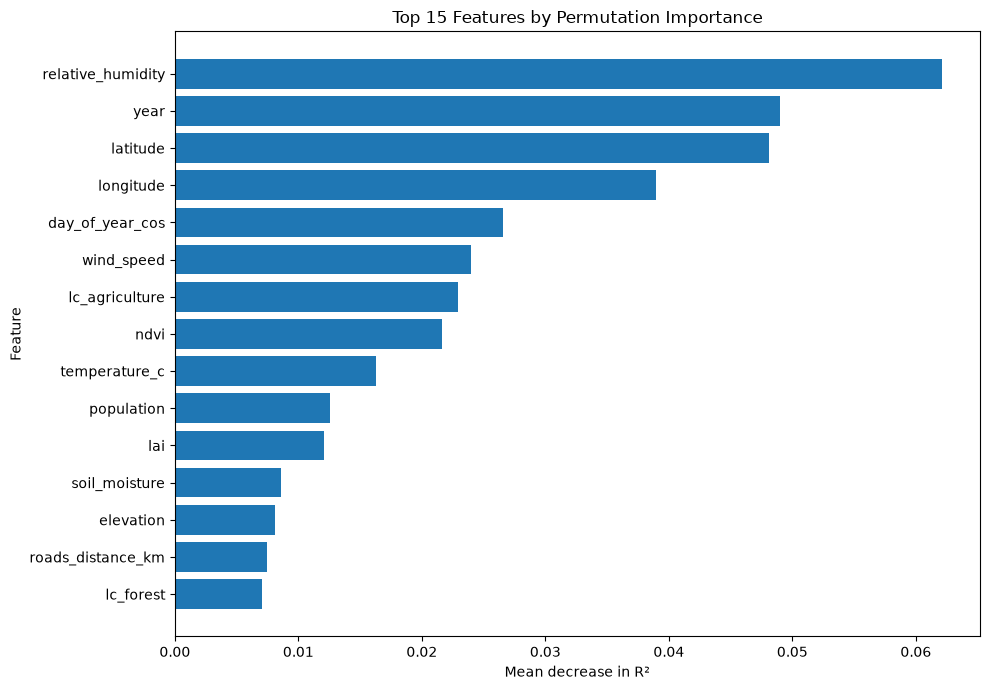

In [37]:
# TOP FEATURE IMPORTANCE
import matplotlib.pyplot as plt

top_n = 15

top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance_Mean"][::-1]
)

plt.xlabel("Mean decrease in R²")
plt.ylabel("Feature")
plt.title("Top 15 Features by Permutation Importance")

plt.tight_layout()
plt.show()

In [38]:
# NEGATIVE FEATURE IMPORTANCE CHECK

negative_features = feature_importance_df[
    feature_importance_df["Importance_Mean"] < 0
]

print("Number of features with negative mean importance:")
print(len(negative_features))

if len(negative_features) > 0:
    print("\nFeatures with negative importance:")
    display(negative_features.round(4))

Number of features with negative mean importance:
5

Features with negative importance:


,Feature,Importance_Mean,Importance_STD
39,solar_radiation,-0.0001,0.0008
40,month_cos,-0.0001,0.0006
41,lc_sparse_vegetation,-0.0002,0.0008
42,month_sin,-0.0002,0.0002
43,wind_direction_missing,-0.0003,0.0002


## Permutation Feature Importance — Interpretation

Permutation Feature Importance was used to investigate which predictor
variables contribute most to the performance of the selected
HistGradientBoosting model.

The results show that **relative humidity** was the most influential feature,
with a mean decrease in testing R² of approximately 0.0621 when its values were
randomly permuted. This indicates that the model relies substantially on
relative humidity when predicting burned area.

Other highly influential features included **year, latitude, longitude,
day-of-year seasonality, wind speed, agricultural land cover, NDVI,
temperature, population, and LAI**.

The importance of relative humidity, wind speed, temperature, NDVI and LAI is
consistent with the role of atmospheric and vegetation conditions in wildfire
behaviour. The importance of land-cover and geographic variables indicates
that spatial characteristics also contribute to the model's predictions.

The relatively high importance of **year** suggests that temporal variation
in the dataset is also being used by the model. However, feature importance
does not establish a causal relationship. In particular, the importance of
latitude, longitude and year indicates that the model is capturing spatial
and temporal patterns present in the dataset rather than demonstrating that
these variables directly cause larger burned areas.

Five features produced slightly negative mean permutation importance values:
`solar_radiation`, `month_cos`, `lc_sparse_vegetation`, `month_sin`, and
`wind_direction_missing`. Their values were very close to zero, ranging from
approximately -0.0001 to -0.0003. These small negative values are likely
associated with permutation variability and interactions or redundancy
between predictors.

The permutation importance results therefore indicate that the final model
primarily relies on a combination of **meteorological, geographical,
vegetation, land-cover and temporal information** rather than a single
predictor.

In [2]:
import shap

print("SHAP version:", shap.__version__)
print("SHAP loaded successfully.")

SHAP version: 0.52.0
SHAP loaded successfully.


In [8]:
from sklearn.ensemble import HistGradientBoostingRegressor

best_hist_model = HistGradientBoostingRegressor(
    min_samples_leaf=30,
    max_leaf_nodes=31,
    max_iter=100,
    max_depth=10,
    learning_rate=0.05,
    l2_regularization=1.0,
    random_state=42
)

best_hist_model.fit(X_train, y_train)

print("Final HistGradientBoosting model trained successfully.")

Final HistGradientBoosting model trained successfully.


In [9]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

hist_train_predictions = best_hist_model.predict(X_train)
hist_test_predictions = best_hist_model.predict(X_test)

print("Final HistGradientBoosting Performance")
print("=" * 50)

print("Train R²  :", round(r2_score(y_train, hist_train_predictions), 4))
print("Test R²   :", round(r2_score(y_test, hist_test_predictions), 4))

print("Train MAE :", round(
    mean_absolute_error(y_train, hist_train_predictions), 4
))

print("Test MAE  :", round(
    mean_absolute_error(y_test, hist_test_predictions), 4
))

print("Train RMSE:", round(
    np.sqrt(mean_squared_error(y_train, hist_train_predictions)), 4
))

print("Test RMSE :", round(
    np.sqrt(mean_squared_error(y_test, hist_test_predictions)), 4
))

Final HistGradientBoosting Performance
Train R²  : 0.4049
Test R²   : 0.2287
Train MAE : 0.7398
Test MAE  : 0.8335
Train RMSE: 0.9271
Test RMSE : 1.0432


In [10]:
# SHAP EXPLAINER

print("Creating SHAP TreeExplainer...")

explainer = shap.TreeExplainer(best_hist_model)

print("SHAP TreeExplainer created successfully.")

Creating SHAP TreeExplainer...
SHAP TreeExplainer created successfully.


In [11]:
# SHAP SAMPLE

X_shap = X_test.sample(
    n=min(500, len(X_test)),
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (500, 44)


In [12]:
# CALCULATE SHAP VALUES

print("Calculating SHAP values...")

shap_values = explainer(X_shap)

print("SHAP calculation completed.")
print("SHAP values shape:", shap_values.values.shape)

Calculating SHAP values...
SHAP calculation completed.
SHAP values shape: (500, 44)


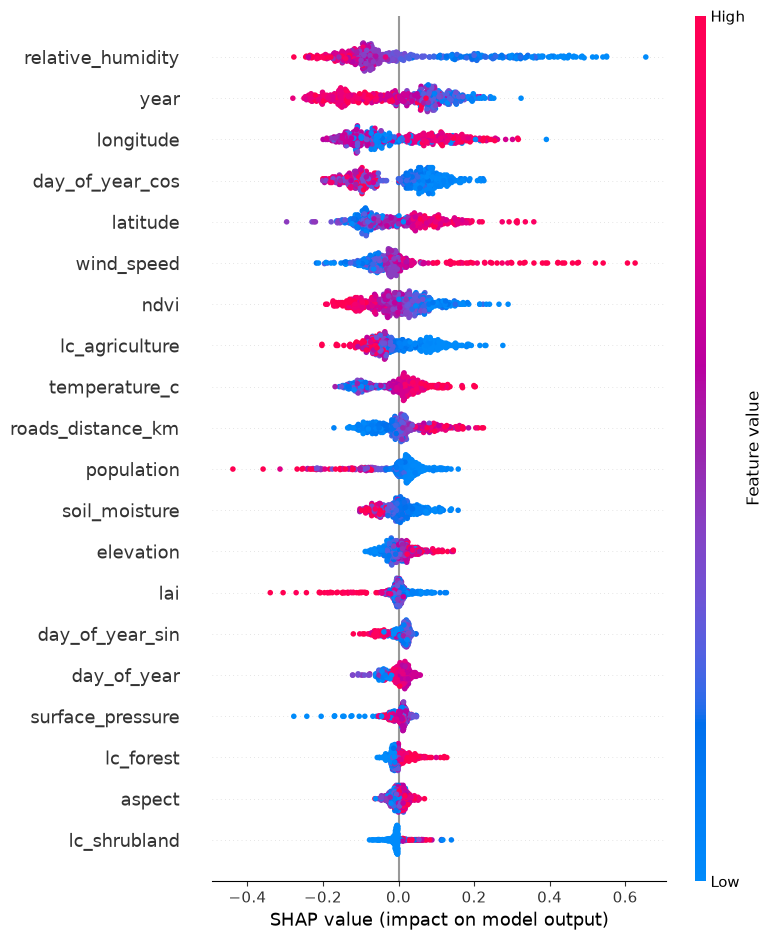

In [13]:
# SHAP SUMMARY PLOT

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=20
)

## SHAP Feature Importance Interpretation

SHAP (SHapley Additive exPlanations) was used to interpret the final
HistGradientBoosting model and identify how individual features influence
the predicted log-transformed burned area.

In the SHAP summary plot, positive SHAP values indicate that a feature
pushes the model prediction towards a larger burned area, while negative
SHAP values indicate a contribution towards a smaller predicted burned
area. Red points represent high feature values and blue points represent
low feature values.

The results show that **relative humidity** is the most influential feature.
Higher relative humidity values are predominantly associated with negative
SHAP values, whereas lower humidity values tend to produce positive
contributions. This indicates that the model generally associates drier
atmospheric conditions with larger predicted burned areas.

**Year**, **longitude**, **latitude**, and **day-of-year seasonal features**
also have substantial influence, indicating that the model captures both
temporal and spatial patterns in wildfire behaviour.

**Wind speed** shows a predominantly positive relationship at higher values,
with high wind-speed observations contributing towards larger predicted
burned areas. Similarly, higher **temperature** values generally produce
positive SHAP contributions.

The model also assigns meaningful importance to environmental and
vegetation-related variables such as **NDVI, LAI, soil moisture, elevation,
and land-cover characteristics**. In particular, lower NDVI and lower soil
moisture values are frequently associated with positive SHAP contributions,
indicating that the model captures relationships between vegetation
conditions and burned-area predictions.

Geographical and human-environment variables such as **population** and
**distance from roads** also contribute to the model predictions. Their
importance suggests that the model captures spatial and human-environment
patterns present in the dataset.

Overall, the SHAP analysis demonstrates that the final model learns from a
combination of **meteorological, geographical, temporal, vegetation,
land-cover, and human-environmental information**. These results improve
the interpretability of the prediction system by showing which variables
contribute most strongly to individual predictions.

The SHAP results represent **model associations rather than causal
relationships**. Therefore, feature importance should not be interpreted as
evidence that a particular variable directly causes an increase or decrease
in burned area.

In [14]:
# SELECT REPRESENTATIVE TEST OBSERVATION

# Select an observation close to the median predicted value
prediction_values = best_hist_model.predict(X_test)

median_prediction = np.median(prediction_values)

representative_idx = np.argmin(
    np.abs(prediction_values - median_prediction)
)

X_instance = X_test.iloc[[representative_idx]]

y_actual_log = y_test.iloc[representative_idx]
y_pred_log = prediction_values[representative_idx]

# Convert back to original burned-area scale
y_actual_ha = np.expm1(y_actual_log)
y_pred_ha = np.expm1(y_pred_log)

print("Representative test observation")
print("=" * 50)

print("Test index:", X_test.index[representative_idx])

print("Actual log burned area:",
      round(y_actual_log, 4))

print("Predicted log burned area:",
      round(y_pred_log, 4))

print("\nActual burned area (ha):",
      round(y_actual_ha, 2))

print("Predicted burned area (ha):",
      round(y_pred_ha, 2))

Representative test observation
Test index: 1988
Actual log burned area: 4.3944
Predicted log burned area: 5.0449

Actual burned area (ha): 80.0
Predicted burned area (ha): 154.23


In [15]:
# INDIVIDUAL SHAP EXPLANATION

individual_shap = explainer(X_instance)

print("Individual SHAP explanation created.")
print("Number of features:", X_instance.shape[1])

Individual SHAP explanation created.
Number of features: 44


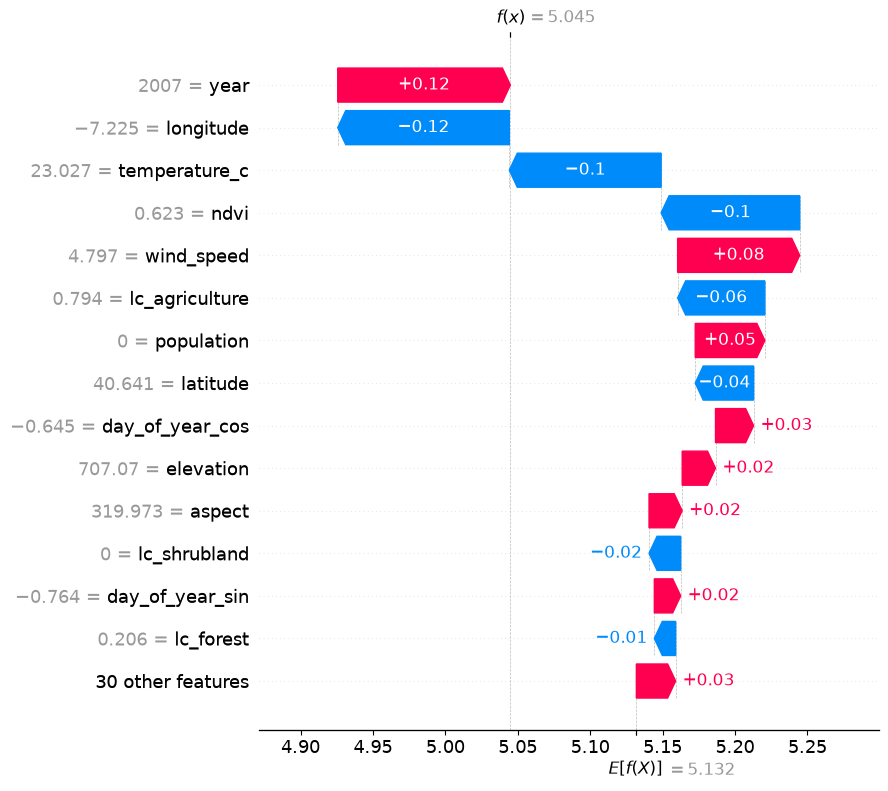

In [16]:
# SHAP WATERFALL PLOT

shap.plots.waterfall(
    individual_shap[0],
    max_display=15
)

In [17]:
# INDIVIDUAL SHAP CONTRIBUTIONS

individual_contributions = pd.DataFrame({
    "Feature": X_instance.columns,
    "Feature_Value": X_instance.iloc[0].values,
    "SHAP_Value": individual_shap.values[0]
})

individual_contributions["Absolute_SHAP"] = (
    individual_contributions["SHAP_Value"].abs()
)

individual_contributions = (
    individual_contributions
    .sort_values("Absolute_SHAP", ascending=False)
    .reset_index(drop=True)
)

display(
    individual_contributions
    .head(15)
    .round(4)
)

,Feature,Feature_Value,SHAP_Value,Absolute_SHAP
0,year,2007.0000,0.1192,0.1192
1,longitude,-7.2252,-0.1185,0.1185
2,temperature_c,23.0269,-0.1048,0.1048
3,ndvi,0.6228,-0.0957,0.0957
4,wind_speed,4.7975,0.0843,0.0843
5,lc_agriculture,0.7941,-0.0602,0.0602
6,population,0.0000,0.0481,0.0481
7,latitude,40.6409,-0.0403,0.0403
8,day_of_year_cos,-0.6453,0.0263,0.0263
9,elevation,707.0701,0.0230,0.0230


In [18]:
# INTERPRET SHAP DIRECTIONS

individual_contributions["Effect"] = np.where(
    individual_contributions["SHAP_Value"] > 0,
    "Increases prediction",
    "Decreases prediction"
)

display(
    individual_contributions[
        [
            "Feature",
            "Feature_Value",
            "SHAP_Value",
            "Effect"
        ]
    ].head(15).round(4)
)

,Feature,Feature_Value,SHAP_Value,Effect
0,year,2007.0000,0.1192,Increases prediction
1,longitude,-7.2252,-0.1185,Decreases prediction
2,temperature_c,23.0269,-0.1048,Decreases prediction
3,ndvi,0.6228,-0.0957,Decreases prediction
4,wind_speed,4.7975,0.0843,Increases prediction
5,lc_agriculture,0.7941,-0.0602,Decreases prediction
6,population,0.0000,0.0481,Increases prediction
7,latitude,40.6409,-0.0403,Decreases prediction
8,day_of_year_cos,-0.6453,0.0263,Increases prediction
9,elevation,707.0701,0.0230,Increases prediction


## Individual Prediction Explanation Using SHAP

A local SHAP explanation was generated for a representative observation
from the test dataset to demonstrate how the final HistGradientBoosting
model produces an individual burned-area prediction.

For test observation 1988, the actual burned area was **80.00 ha**, while
the model predicted **154.23 ha**. On the logarithmic target scale, the
actual value was 4.3944 and the predicted value was 5.0449.

The SHAP waterfall plot shows how individual features moved the prediction
away from the model's average output of approximately 5.132 on the
log-transformed scale.

The strongest positive contributions were associated with **year,
wind speed, population, day-of-year seasonal features, elevation, and
aspect**. These features pushed the model prediction towards a larger
burned-area estimate.

Conversely, **longitude, temperature, NDVI, agricultural land cover, and
latitude** produced some of the strongest negative contributions, reducing
the predicted burned area.

The individual explanation demonstrates that the model does not base a
prediction on a single variable. Instead, the final prediction results from
the combined contribution of meteorological, geographical, vegetation,
land-cover, and temporal characteristics.

The difference between the actual and predicted burned area also
demonstrates the importance of model explainability. Although the model
overestimated this particular observation, SHAP provides a transparent
way to identify which input characteristics contributed to that prediction.

It should be noted that SHAP values explain the model's prediction on the
**log(1 + burned area)** scale. They represent contributions to the model
output and should not be interpreted as direct changes in burned area in
hectares. Furthermore, SHAP identifies model associations rather than
causal relationships.

In [19]:
# PREDICTION BIAS ANALYSIS

bias_analysis = pd.DataFrame({
    "Actual_Log": y_test.values,
    "Predicted_Log": hist_test_predictions
})

bias_analysis["Error"] = (
    bias_analysis["Predicted_Log"] -
    bias_analysis["Actual_Log"]
)

print("Prediction Bias Analysis")
print("=" * 50)

print("Mean Error:",
      round(bias_analysis["Error"].mean(), 4))

print("Median Error:",
      round(bias_analysis["Error"].median(), 4))

print("Mean Absolute Error:",
      round(bias_analysis["Error"].abs().mean(), 4))

print("\nOverpredictions:",
      (bias_analysis["Error"] > 0).sum())

print("Underpredictions:",
      (bias_analysis["Error"] < 0).sum())

print("Exact/near-zero errors:",
      (bias_analysis["Error"] == 0).sum())

Prediction Bias Analysis
Mean Error: 0.0402
Median Error: 0.2121
Mean Absolute Error: 0.8335

Overpredictions: 1298
Underpredictions: 963
Exact/near-zero errors: 0


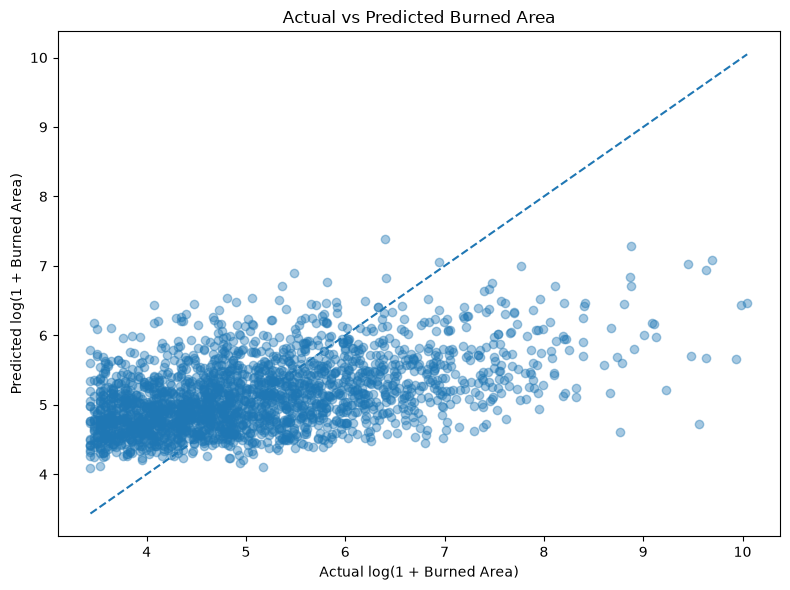

In [20]:
# ACTUAL VS PREDICTED BURNED AREA

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    hist_test_predictions,
    alpha=0.4
)

# Perfect prediction line
min_value = min(y_test.min(), hist_test_predictions.min())
max_value = max(y_test.max(), hist_test_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual log(1 + Burned Area)")
plt.ylabel("Predicted log(1 + Burned Area)")
plt.title("Actual vs Predicted Burned Area")

plt.tight_layout()
plt.show()

In [21]:
# ERROR ANALYSIS BY BURNED-AREA RANGE

# Convert log target back to hectares
actual_ha = np.expm1(y_test.values)
predicted_ha = np.expm1(hist_test_predictions)

error_by_range = pd.DataFrame({
    "actual_ha": actual_ha,
    "predicted_ha": predicted_ha
})

error_by_range["error_ha"] = (
    error_by_range["predicted_ha"] -
    error_by_range["actual_ha"]
)

error_by_range["absolute_error_ha"] = (
    error_by_range["error_ha"].abs()
)

# Define burned-area groups
bins = [0, 100, 500, 5000, 10000, np.inf]

labels = [
    "30–100 ha",
    "101–500 ha",
    "501–5,000 ha",
    "5,001–10,000 ha",
    ">10,000 ha"
]

error_by_range["burned_area_range"] = pd.cut(
    error_by_range["actual_ha"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

range_summary = (
    error_by_range
    .groupby("burned_area_range", observed=False)
    .agg(
        records=("actual_ha", "count"),
        mean_actual_ha=("actual_ha", "mean"),
        mean_predicted_ha=("predicted_ha", "mean"),
        mean_error_ha=("error_ha", "mean"),
        MAE_ha=("absolute_error_ha", "mean")
    )
    .reset_index()
)

display(range_summary.round(2))

,burned_area_range,records,mean_actual_ha,mean_predicted_ha,mean_error_ha,MAE_ha
0,30–100 ha,918,58.14,145.78,87.63,87.91
1,101–500 ha,971,222.15,197.92,-24.23,106.34
2,"501–5,000 ha",347,1301.07,283.75,-1017.32,1026.31
3,"5,001–10,000 ha",15,7128.47,498.28,-6630.19,6630.19
4,">10,000 ha",10,16222.80,578.62,-15644.18,15644.18


### Create training weights

In [22]:
# CREATE TARGET-BASED SAMPLE WEIGHTS


# Calculate thresholds using TRAINING TARGET ONLY
p90 = y_train.quantile(0.90)
p95 = y_train.quantile(0.95)
p99 = y_train.quantile(0.99)
p995 = y_train.quantile(0.995)

print("Training target weighting thresholds:")
print("90th percentile :", round(p90, 4))
print("95th percentile :", round(p95, 4))
print("99th percentile :", round(p99, 4))
print("99.5th percentile:", round(p995, 4))

# Default weight
sample_weights = np.ones(len(y_train))

# Apply progressively larger weights
sample_weights[y_train >= p90] = 1.5
sample_weights[y_train >= p95] = 2.0
sample_weights[y_train >= p99] = 3.0
sample_weights[y_train >= p995] = 4.0

print("\nSample-weight distribution:")

weight_summary = pd.Series(sample_weights).value_counts().sort_index()

display(
    weight_summary.rename("records").to_frame()
)

Training target weighting thresholds:
90th percentile : 6.7708
95th percentile : 7.4182
99th percentile : 8.6881
99.5th percentile: 9.2471

Sample-weight distribution:


,records
1.0,8136
1.5,452
2.0,363
3.0,45
4.0,46


In [23]:
# WEIGHT VALIDATION

weight_check = pd.DataFrame({
    "target": y_train.values,
    "weight": sample_weights
})

weight_check["target_percentile"] = (
    weight_check["target"]
    .rank(pct=True) * 100
)

display(
    weight_check
    .sort_values("target", ascending=False)
    .head(20)
)

,target,weight,target_percentile
7532,11.586204,4.0,100.000000
4335,11.120209,4.0,99.988940
9010,10.910898,4.0,99.977881
5133,10.844393,4.0,99.966821
6859,10.752997,4.0,99.955762
3694,10.732258,4.0,99.944702
4511,10.653747,4.0,99.933643
2546,10.389887,4.0,99.922583
2048,10.386685,4.0,99.911524
8710,10.241637,4.0,99.900464


In [24]:
# TRAIN WEIGHTED HISTGRADIENTBOOSTING

weighted_hist_model = HistGradientBoostingRegressor(
    min_samples_leaf=30,
    max_leaf_nodes=31,
    max_iter=100,
    max_depth=10,
    learning_rate=0.05,
    l2_regularization=1.0,
    random_state=42
)

weighted_hist_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

print("Weighted HistGradientBoosting model trained successfully.")

Weighted HistGradientBoosting model trained successfully.


In [25]:
# EVALUATE WEIGHTED MODEL

weighted_train_predictions = weighted_hist_model.predict(X_train)
weighted_test_predictions = weighted_hist_model.predict(X_test)

weighted_results = {
    "Model": "Weighted HistGradientBoosting",
    "Train R²": r2_score(
        y_train,
        weighted_train_predictions
    ),
    "Test R²": r2_score(
        y_test,
        weighted_test_predictions
    ),
    "Train MAE": mean_absolute_error(
        y_train,
        weighted_train_predictions
    ),
    "Test MAE": mean_absolute_error(
        y_test,
        weighted_test_predictions
    ),
    "Train RMSE": np.sqrt(
        mean_squared_error(
            y_train,
            weighted_train_predictions
        )
    ),
    "Test RMSE": np.sqrt(
        mean_squared_error(
            y_test,
            weighted_test_predictions
        )
    )
}

display(
    pd.DataFrame([weighted_results]).round(4)
)

,Model,Train R²,Test R²,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Weighted HistGradientBoosting,0.4234,0.2066,0.7495,0.8567,0.9126,1.058


In [26]:
# WEIGHTED MODEL — ERROR BY BURNED-AREA RANGE

weighted_actual_ha = np.expm1(y_test.values)
weighted_predicted_ha = np.expm1(weighted_test_predictions)

weighted_error = pd.DataFrame({
    "actual_ha": weighted_actual_ha,
    "predicted_ha": weighted_predicted_ha
})

weighted_error["error_ha"] = (
    weighted_error["predicted_ha"] -
    weighted_error["actual_ha"]
)

weighted_error["absolute_error_ha"] = (
    weighted_error["error_ha"].abs()
)

weighted_error["burned_area_range"] = pd.cut(
    weighted_error["actual_ha"],
    bins=[0, 100, 500, 5000, 10000, np.inf],
    labels=[
        "30–100 ha",
        "101–500 ha",
        "501–5,000 ha",
        "5,001–10,000 ha",
        ">10,000 ha"
    ],
    include_lowest=True
)

weighted_range_summary = (
    weighted_error
    .groupby(
        "burned_area_range",
        observed=False
    )
    .agg(
        records=("actual_ha", "count"),
        mean_actual_ha=("actual_ha", "mean"),
        mean_predicted_ha=("predicted_ha", "mean"),
        mean_error_ha=("error_ha", "mean"),
        MAE_ha=("absolute_error_ha", "mean")
    )
    .reset_index()
)

display(
    weighted_range_summary.round(2)
)

,burned_area_range,records,mean_actual_ha,mean_predicted_ha,mean_error_ha,MAE_ha
0,30–100 ha,918,58.14,167.51,109.37,109.60
1,101–500 ha,971,222.15,241.30,19.15,131.93
2,"501–5,000 ha",347,1301.07,369.82,-931.25,956.49
3,"5,001–10,000 ha",15,7128.47,729.34,-6399.12,6399.12
4,">10,000 ha",10,16222.80,1282.24,-14940.56,14940.56


## Evaluation of Target-Weighted HistGradientBoosting

A target-weighted version of the HistGradientBoosting model was evaluated
to determine whether giving greater importance to rare high burned-area
observations could improve predictions for extreme wildfire events.

Training observations above the 90th, 95th, 99th, and 99.5th target
percentiles were assigned progressively higher weights of 1.5, 2.0, 3.0,
and 4.0 respectively. The weighting thresholds were calculated using the
training data only to avoid data leakage.

The weighted model produced a testing R² of **0.2066**, compared with
**0.2287** for the original HistGradientBoosting model. The testing MAE
also increased from **0.8335 to 0.8567**, while the testing RMSE increased
from **1.0432 to 1.0580**.

Although target weighting improved the predicted burned-area values for
some larger-fire groups, the improvement was not sufficient to compensate
for the reduction in overall predictive performance. The weighted model
also continued to substantially underestimate the most extreme burned-area
observations.

Therefore, the original HistGradientBoosting model was retained as the
final model because it provided better overall generalisation performance
on the unseen test data.

This experiment also demonstrates an important limitation of the dataset:
rare extreme wildfire events remain difficult to predict accurately, even
when additional emphasis is placed on these observations during training.

### Severity-Aware Two-Stage Modelling

In [27]:
# STAGE 1 — CREATE FIRE SEVERITY LABELS

# Convert the log-transformed target back to hectares
train_burned_area_ha = np.expm1(y_train)

test_burned_area_ha = np.expm1(y_test)

# Define severity threshold
severity_threshold = 500

# 0 = Normal fire (<= 500 ha)
# 1 = Large fire (> 500 ha)

y_train_severity = (
    train_burned_area_ha > severity_threshold
).astype(int)

y_test_severity = (
    test_burned_area_ha > severity_threshold
).astype(int)

print("Fire severity threshold:", severity_threshold, "ha")

print("\nTraining severity distribution:")
print(
    pd.Series(y_train_severity)
    .value_counts()
    .sort_index()
)

print("\nTesting severity distribution:")
print(
    pd.Series(y_test_severity)
    .value_counts()
    .sort_index()
)

Fire severity threshold: 500 ha

Training severity distribution:
log_burned_area
0    7426
1    1616
Name: count, dtype: int64

Testing severity distribution:
log_burned_area
0    1889
1     372
Name: count, dtype: int64


In [28]:
from sklearn.ensemble import HistGradientBoostingClassifier

severity_classifier = HistGradientBoostingClassifier(
    max_iter=150,
    max_leaf_nodes=31,
    learning_rate=0.05,
    min_samples_leaf=30,
    l2_regularization=1.0,
    random_state=42
)

severity_classifier.fit(
    X_train,
    y_train_severity
)

print("Severity classifier trained successfully.")

Severity classifier trained successfully.


In [29]:
# EVALUATE SEVERITY CLASSIFIER

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

severity_train_pred = severity_classifier.predict(X_train)
severity_test_pred = severity_classifier.predict(X_test)

print("Severity Classification Performance")
print("=" * 50)

print("Training Accuracy:",
      round(accuracy_score(
          y_train_severity,
          severity_train_pred
      ), 4))

print("Testing Accuracy:",
      round(accuracy_score(
          y_test_severity,
          severity_test_pred
      ), 4))

print("Testing Precision:",
      round(precision_score(
          y_test_severity,
          severity_test_pred,
          zero_division=0
      ), 4))

print("Testing Recall:",
      round(recall_score(
          y_test_severity,
          severity_test_pred,
          zero_division=0
      ), 4))

print("Testing F1:",
      round(f1_score(
          y_test_severity,
          severity_test_pred,
          zero_division=0
      ), 4))

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_severity,
        severity_test_pred
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_severity,
        severity_test_pred,
        target_names=[
            "Normal Fire",
            "Large Fire"
        ],
        zero_division=0
    )
)

Severity Classification Performance
Training Accuracy: 0.8887
Testing Accuracy: 0.839
Testing Precision: 0.5417
Testing Recall: 0.1398
Testing F1: 0.2222

Confusion Matrix:
[[1845   44]
 [ 320   52]]

Classification Report:
              precision    recall  f1-score   support

 Normal Fire       0.85      0.98      0.91      1889
  Large Fire       0.54      0.14      0.22       372

    accuracy                           0.84      2261
   macro avg       0.70      0.56      0.57      2261
weighted avg       0.80      0.84      0.80      2261



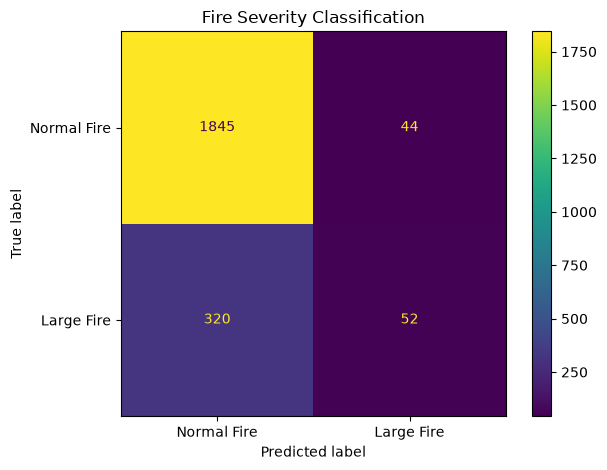

In [30]:
# SEVERITY CONFUSION MATRIX

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test_severity,
    severity_test_pred,
    display_labels=[
        "Normal Fire",
        "Large Fire"
    ]
)

plt.title("Fire Severity Classification")
plt.tight_layout()
plt.show()

## Initial Severity Classification Results

The initial severity classifier achieved a testing accuracy of **83.9%**.
However, accuracy alone does not provide a reliable assessment because
normal fires substantially outnumber large fires.

The classifier achieved a precision of **54.17%** and a recall of only
**13.98%** for the large-fire class, resulting in an F1-score of **22.22%**.

The confusion matrix shows that the classifier correctly identified only
**52 of the 372 actual large-fire observations**, while **320 large fires
were incorrectly classified as normal fires**.

Although the classifier achieves relatively high overall accuracy, its
ability to identify large fires is currently insufficient for the proposed
two-stage prediction architecture.

The classifier is therefore not yet suitable for routing observations to
a specialised large-fire regression model. A probability-threshold
analysis will next be performed using a validation subset of the training
data to investigate whether the recall of the large-fire class can be
improved without excessively reducing precision.

Importantly, the testing dataset will remain untouched during threshold
selection to prevent data leakage.

In [31]:
# CREATE VALIDATION SET FOR SEVERITY THRESHOLD TUNING

from sklearn.model_selection import train_test_split

X_severity_train, X_severity_val, y_severity_train, y_severity_val = (
    train_test_split(
        X_train,
        y_train_severity,
        test_size=0.20,
        stratify=y_train_severity,
        random_state=42
    )
)

print("Severity training set:", X_severity_train.shape)
print("Severity validation set:", X_severity_val.shape)

print("\nTraining severity distribution:")
print(y_severity_train.value_counts().sort_index())

print("\nValidation severity distribution:")
print(y_severity_val.value_counts().sort_index())

Severity training set: (7233, 44)
Severity validation set: (1809, 44)

Training severity distribution:
log_burned_area
0    5940
1    1293
Name: count, dtype: int64

Validation severity distribution:
log_burned_area
0    1486
1     323
Name: count, dtype: int64


## Validation Set for Threshold Selection

Because the initial classifier produced a low recall for large fires,
different classification probability thresholds will be investigated.

A validation subset was therefore created from the training data using an
80/20 stratified split. Stratification ensures that the proportion of
normal and large fires remains approximately consistent between the
training and validation subsets.

The original testing dataset is not used during this threshold-selection
process. This separation ensures that the final test results remain an
unbiased estimate of model performance on unseen data.

The validation set will be used only to determine an appropriate
probability threshold for identifying potential large-fire events.

In [32]:
# TRAIN SEVERITY CLASSIFIER FOR THRESHOLD TUNING

severity_threshold_model = HistGradientBoostingClassifier(
    max_iter=150,
    max_leaf_nodes=31,
    learning_rate=0.05,
    min_samples_leaf=30,
    l2_regularization=1.0,
    random_state=42
)

severity_threshold_model.fit(
    X_severity_train,
    y_severity_train
)

print("Validation classifier trained successfully.")

Validation classifier trained successfully.


## Training the Threshold-Tuning Classifier

A separate HistGradientBoostingClassifier was trained using the reduced
severity-training subset.

This model is used specifically for determining the probability threshold
for large-fire classification. It is not yet the final classifier.

The validation observations remain unseen during training and will be used
to evaluate how different probability thresholds affect the balance
between large-fire precision and recall.

In [33]:
# GET LARGE-FIRE PROBABILITIES

validation_large_probability = (
    severity_threshold_model
    .predict_proba(X_severity_val)[:, 1]
)

print("Probability range:")
print(
    "Minimum:",
    round(validation_large_probability.min(), 4)
)

print(
    "Maximum:",
    round(validation_large_probability.max(), 4)
)

print(
    "Mean:",
    round(validation_large_probability.mean(), 4)
)

Probability range:
Minimum: 0.0079
Maximum: 0.8049
Mean: 0.1747


## Large-Fire Probability Estimation

Instead of producing only a binary normal/large prediction, the classifier
was used to estimate the probability that each validation observation
belongs to the large-fire class.

These probabilities allow different classification thresholds to be
tested.

For example, using a threshold of 0.50 means that an observation is
classified as a large fire only when its estimated probability is at least
50%. Lowering the threshold makes the classifier more sensitive to
potential large-fire events, which may increase recall but also produce
more false positives.

This threshold trade-off is particularly important for the present
application because failing to identify a genuine large-fire event may be
more significant than incorrectly flagging a normal fire as potentially
large.

In [34]:
# TEST SEVERITY CLASSIFICATION THRESHOLDS

from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

thresholds = [
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]

for threshold in thresholds:

    validation_prediction = (
        validation_large_probability >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_severity_val,
            validation_prediction,
            zero_division=0
        ),
        "Recall": recall_score(
            y_severity_val,
            validation_prediction,
            zero_division=0
        ),
        "F1": f1_score(
            y_severity_val,
            validation_prediction,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(threshold_results)

display(
    threshold_results.round(4)
)

,Threshold,Precision,Recall,F1
0,0.10,0.2647,0.8916,0.4082
1,0.15,0.3019,0.7523,0.4309
2,0.20,0.3560,0.6471,0.4593
3,0.25,0.4014,0.5294,0.4566
4,0.30,0.4281,0.4241,0.4261
5,0.35,0.4632,0.3313,0.3863
6,0.40,0.4756,0.2415,0.3203
7,0.45,0.4793,0.1796,0.2613
8,0.50,0.4940,0.1269,0.2020


## Probability Threshold Selection

The validation results demonstrate a clear trade-off between precision and
recall as the large-fire classification threshold is changed.

At the default threshold of 0.50, the classifier achieves a large-fire
recall of only 12.69%. Lowering the threshold substantially increases the
ability of the classifier to identify potential large-fire events.

A threshold of **0.20** was selected because it produced the highest
validation F1-score of **0.4593**, with a precision of **0.3560** and a
recall of **0.6471** for the large-fire class.

This means that the selected threshold identifies approximately 64.7% of
large-fire observations in the validation data, although some normal fires
are also classified as potential large fires.

A threshold of 0.10 achieved higher recall (89.16%) but produced
substantially lower precision (26.47%), resulting in more false-positive
large-fire classifications. Therefore, the 0.20 threshold provides a more
balanced trade-off between large-fire detection and false alarms.

The threshold was selected using validation data derived from the training
set only. The independent test dataset was not used during threshold
selection, preventing test-set leakage.

In [35]:
# FINAL SEVERITY CLASSIFIER WITH SELECTED THRESHOLD

selected_severity_threshold = 0.20

final_severity_classifier = HistGradientBoostingClassifier(
    max_iter=150,
    max_leaf_nodes=31,
    learning_rate=0.05,
    min_samples_leaf=30,
    l2_regularization=1.0,
    random_state=42
)

# Train using the COMPLETE training dataset
final_severity_classifier.fit(
    X_train,
    y_train_severity
)

print("Final severity classifier trained.")
print(
    "Selected large-fire probability threshold:",
    selected_severity_threshold
)

Final severity classifier trained.
Selected large-fire probability threshold: 0.2


## Final Severity Classifier

Following threshold analysis, a probability threshold of **0.20** was
selected based on the validation F1-score.

The severity classifier was then retrained using the complete training
dataset while keeping the independent testing dataset completely unseen.

The selected threshold will be applied to the predicted probability of the
large-fire class during final testing.

This approach ensures that both the classifier parameters and the selected
probability threshold are determined without using information from the
final test set.

In [36]:
# FINAL TESTING OF SEVERITY CLASSIFIER

test_large_probability = (
    final_severity_classifier
    .predict_proba(X_test)[:, 1]
)

final_severity_test_pred = (
    test_large_probability >= selected_severity_threshold
).astype(int)

print("Final Severity Classification")
print("=" * 50)

print("Testing Precision:",
      round(
          precision_score(
              y_test_severity,
              final_severity_test_pred,
              zero_division=0
          ),
          4
      ))

print("Testing Recall:",
      round(
          recall_score(
              y_test_severity,
              final_severity_test_pred,
              zero_division=0
          ),
          4
      ))

print("Testing F1:",
      round(
          f1_score(
              y_test_severity,
              final_severity_test_pred,
              zero_division=0
          ),
          4
      ))

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_severity,
        final_severity_test_pred
    )
)

Final Severity Classification
Testing Precision: 0.348
Testing Recall: 0.6371
Testing F1: 0.4501

Confusion Matrix:
[[1445  444]
 [ 135  237]]


In [37]:
# PREPARE SEVERITY-SPECIFIC REGRESSION DATA

# Training masks
normal_train_mask = train_burned_area_ha <= severity_threshold
large_train_mask = train_burned_area_ha > severity_threshold

# Create specialised training datasets
X_train_normal = X_train.loc[normal_train_mask].copy()
y_train_normal = y_train.loc[normal_train_mask].copy()

X_train_large = X_train.loc[large_train_mask].copy()
y_train_large = y_train.loc[large_train_mask].copy()

print("Normal-fire training records:", len(X_train_normal))
print("Large-fire training records:", len(X_train_large))

print("\nNormal-fire target range:")
print(
    np.expm1(y_train_normal.min()),
    "to",
    np.expm1(y_train_normal.max()),
    "ha"
)

print("\nLarge-fire target range:")
print(
    np.expm1(y_train_large.min()),
    "to",
    np.expm1(y_train_large.max()),
    "ha"
)

Normal-fire training records: 7426
Large-fire training records: 1616

Normal-fire target range:
30.0 to 499.9999999999999 ha

Large-fire target range:
500.99999999999983 to 107601.99999999988 ha


In [ ]:
#  TRAIN NORMAL-FIRE REGRESSOR

normal_fire_model = HistGradientBoostingRegressor(
    min_samples_leaf=30,
    max_leaf_nodes=31,
    max_iter=100,
    max_depth=10,
    learning_rate=0.05,
    l2_regularization=1.0,
    random_state=42
)

normal_fire_model.fit(
    X_train_normal,
    y_train_normal
)

print("Normal-fire regressor trained successfully.")

Normal-fire regressor trained successfully.


In [39]:
# TRAIN LARGE-FIRE REGRESSOR

large_fire_model = HistGradientBoostingRegressor(
    min_samples_leaf=15,
    max_leaf_nodes=31,
    max_iter=150,
    max_depth=10,
    learning_rate=0.05,
    l2_regularization=1.0,
    random_state=42
)

large_fire_model.fit(
    X_train_large,
    y_train_large
)

print("Large-fire regressor trained successfully.")

Large-fire regressor trained successfully.


In [40]:
# EVALUATE NORMAL-FIRE REGRESSOR

normal_train_pred = normal_fire_model.predict(X_train_normal)

normal_test_mask = test_burned_area_ha <= severity_threshold

X_test_normal = X_test.loc[normal_test_mask]
y_test_normal = y_test.loc[normal_test_mask]

normal_test_pred = normal_fire_model.predict(X_test_normal)

normal_results = {
    "Model": "Normal-Fire Regressor",
    "Train R²": r2_score(y_train_normal, normal_train_pred),
    "Test R²": r2_score(y_test_normal, normal_test_pred),
    "Train MAE": mean_absolute_error(y_train_normal, normal_train_pred),
    "Test MAE": mean_absolute_error(y_test_normal, normal_test_pred),
    "Train RMSE": np.sqrt(mean_squared_error(y_train_normal, normal_train_pred)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test_normal, normal_test_pred))
}

display(
    pd.DataFrame([normal_results]).round(4)
)

,Model,Train R²,Test R²,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Normal-Fire Regressor,0.3325,0.0981,0.5108,0.6005,0.6085,0.7176


In [41]:
# EVALUATE LARGE-FIRE REGRESSOR

large_train_pred = large_fire_model.predict(X_train_large)

large_test_mask = test_burned_area_ha > severity_threshold

X_test_large = X_test.loc[large_test_mask]
y_test_large = y_test.loc[large_test_mask]

large_test_pred = large_fire_model.predict(X_test_large)

large_results = {
    "Model": "Large-Fire Regressor",
    "Train R²": r2_score(y_train_large, large_train_pred),
    "Test R²": r2_score(y_test_large, large_test_pred),
    "Train MAE": mean_absolute_error(y_train_large, large_train_pred),
    "Test MAE": mean_absolute_error(y_test_large, large_test_pred),
    "Train RMSE": np.sqrt(mean_squared_error(y_train_large, large_train_pred)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test_large, large_test_pred))
}

display(
    pd.DataFrame([large_results]).round(4)
)

,Model,Train R²,Test R²,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Large-Fire Regressor,0.8274,0.0003,0.2648,0.61,0.345,0.786


In [42]:
# STAGE 3 — TWO-STAGE FIRE AREA PREDICTION

# Generate predictions from both specialised models
normal_predictions_all = normal_fire_model.predict(X_test)
large_predictions_all = large_fire_model.predict(X_test)

# Use the final severity classifier probabilities
test_large_probability = (
    final_severity_classifier.predict_proba(X_test)[:, 1]
)

# Route each observation to the appropriate regressor
two_stage_predictions = np.where(
    test_large_probability >= selected_severity_threshold,
    large_predictions_all,
    normal_predictions_all
)

print("Two-stage predictions generated successfully.")

print("\nPrediction shape:")
print(two_stage_predictions.shape)

print("\nPrediction range:")
print(
    "Minimum:",
    round(two_stage_predictions.min(), 4)
)

print(
    "Maximum:",
    round(two_stage_predictions.max(), 4)
)

Two-stage predictions generated successfully.

Prediction shape:
(2261,)

Prediction range:
Minimum: 3.8986
Maximum: 8.6097


In [43]:
# EVALUATE TWO-STAGE MODEL

two_stage_results = {
    "Model": "Two-Stage Severity-Aware Model",
    "Test R²": r2_score(
        y_test,
        two_stage_predictions
    ),
    "Test MAE": mean_absolute_error(
        y_test,
        two_stage_predictions
    ),
    "Test RMSE": np.sqrt(
        mean_squared_error(
            y_test,
            two_stage_predictions
        )
    )
}

display(
    pd.DataFrame([two_stage_results]).round(4)
)

,Model,Test R²,Test MAE,Test RMSE
0,Two-Stage Severity-Aware Model,-0.2378,1.0029,1.3215


In [44]:
# COMPARE TWO-STAGE MODEL WITH BEST BASELINE

comparison = pd.DataFrame([
    {
        "Model": "Tuned HistGradientBoosting",
        "Test R²": 0.2287,
        "Test MAE": 0.8335,
        "Test RMSE": 1.0432
    },
    {
        "Model": "Two-Stage Severity-Aware",
        "Test R²": two_stage_results["Test R²"],
        "Test MAE": two_stage_results["Test MAE"],
        "Test RMSE": two_stage_results["Test RMSE"]
    }
])

display(
    comparison.round(4)
)

,Model,Test R²,Test MAE,Test RMSE
0,Tuned HistGradientBoosting,0.2287,0.8335,1.0432
1,Two-Stage Severity-Aware,-0.2378,1.0029,1.3215


## Severity-Aware Two-Stage Modelling — Final Evaluation

A two-stage modelling architecture was investigated to address the poor
prediction of large burned-area events. The first stage classified fires
as either normal fires (≤500 ha) or large fires (>500 ha), while the second
stage used separate regression models for each severity category.

Although probability-threshold tuning improved the large-fire classifier,
the specialised regression models did not generalise sufficiently to
unseen data. The large-fire regressor achieved a training R² of 0.8274 but
a testing R² of only 0.0003, indicating substantial overfitting.

When the classifier and specialised regressors were combined into a
complete two-stage prediction system, the model achieved a testing R² of
**−0.2378**, with a testing MAE of **1.0029** and RMSE of **1.3215**.

This performance was substantially worse than the tuned
HistGradientBoosting baseline, which achieved a testing R² of **0.2287**,
MAE of **0.8335**, and RMSE of **1.0432**.

Therefore, the severity-aware two-stage architecture was not selected as
the final prediction model. The experiment demonstrates that explicitly
separating normal and large fires does not improve generalisation for the
current dataset, likely due to the limited number and high variability of
large-fire observations.

The tuned HistGradientBoosting model therefore remains the strongest
single-model candidate at this stage.

In [45]:
# ENSEMBLE — CREATE VALIDATION SET

from sklearn.model_selection import train_test_split

X_ensemble_train, X_ensemble_val, y_ensemble_train, y_ensemble_val = (
    train_test_split(
        X_train,
        y_train,
        test_size=0.20,
        random_state=42
    )
)

print("Ensemble training set:", X_ensemble_train.shape)
print("Ensemble validation set:", X_ensemble_val.shape)

Ensemble training set: (7233, 44)
Ensemble validation set: (1809, 44)


## Ensemble Validation Strategy

A validation subset was created from the training data to determine
appropriate ensemble weights without using the independent testing data.

The original testing dataset remains completely untouched. This prevents
the test set from influencing model selection and ensures that the final
ensemble performance provides an unbiased estimate of generalisation.

In [47]:
# ENSEMBLE — TRAIN BASE MODELS

from sklearn.ensemble import RandomForestRegressor

ensemble_hist_model = HistGradientBoostingRegressor(
    min_samples_leaf=30,
    max_leaf_nodes=31,
    max_iter=100,
    max_depth=10,
    learning_rate=0.05,
    l2_regularization=1.0,
    random_state=42
)

ensemble_rf_model = RandomForestRegressor(
    n_estimators=500,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features=0.7,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

ensemble_hist_model.fit(
    X_ensemble_train,
    y_ensemble_train
)

ensemble_rf_model.fit(
    X_ensemble_train,
    y_ensemble_train
)

print("Ensemble base models trained successfully.")

Ensemble base models trained successfully.


In [48]:
# ENSEMBLE — VALIDATION PREDICTIONS

hist_val_pred = ensemble_hist_model.predict(
    X_ensemble_val
)

rf_val_pred = ensemble_rf_model.predict(
    X_ensemble_val
)

print("Validation predictions generated.")

Validation predictions generated.


In [49]:
# ENSEMBLE — WEIGHT SEARCH


ensemble_results = []

weights = np.arange(0.0, 1.01, 0.05)

for hist_weight in weights:

    rf_weight = 1.0 - hist_weight

    ensemble_val_pred = (
        hist_weight * hist_val_pred
        + rf_weight * rf_val_pred
    )

    ensemble_results.append({
        "HistWeight": hist_weight,
        "RFWeight": rf_weight,
        "Validation R2": r2_score(
            y_ensemble_val,
            ensemble_val_pred
        ),
        "Validation MAE": mean_absolute_error(
            y_ensemble_val,
            ensemble_val_pred
        ),
        "Validation RMSE": np.sqrt(
            mean_squared_error(
                y_ensemble_val,
                ensemble_val_pred
            )
        )
    })

ensemble_results = pd.DataFrame(
    ensemble_results
)

display(
    ensemble_results
    .sort_values(
        "Validation R2",
        ascending=False
    )
    .round(4)
)

,HistWeight,RFWeight,Validation R2,Validation MAE,Validation RMSE
14,0.70,0.30,0.1933,0.8333,1.0564
13,0.65,0.35,0.1932,0.8335,1.0565
15,0.75,0.25,0.1932,0.8333,1.0565
12,0.60,0.40,0.1931,0.8336,1.0566
16,0.80,0.20,0.1931,0.8333,1.0566
11,0.55,0.45,0.1928,0.8338,1.0568
17,0.85,0.15,0.1927,0.8334,1.0568
10,0.50,0.50,0.1924,0.8340,1.0571
18,0.90,0.10,0.1923,0.8335,1.0571
9,0.45,0.55,0.1918,0.8343,1.0574


In [50]:
# FINAL ENSEMBLE — TRAIN ON COMPLETE TRAINING DATA

final_ensemble_hist = HistGradientBoostingRegressor(
    min_samples_leaf=30,
    max_leaf_nodes=31,
    max_iter=100,
    max_depth=10,
    learning_rate=0.05,
    l2_regularization=1.0,
    random_state=42
)

final_ensemble_rf = RandomForestRegressor(
    n_estimators=500,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features=0.7,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

final_ensemble_hist.fit(
    X_train,
    y_train
)

final_ensemble_rf.fit(
    X_train,
    y_train
)

print("Final ensemble models trained successfully.")

Final ensemble models trained successfully.


In [51]:
# FINAL ENSEMBLE PREDICTIONS

final_hist_test_pred = final_ensemble_hist.predict(X_test)

final_rf_test_pred = final_ensemble_rf.predict(X_test)

# Selected validation weights
hist_weight = 0.70
rf_weight = 0.30

final_ensemble_test_pred = (
    hist_weight * final_hist_test_pred
    + rf_weight * final_rf_test_pred
)

print("Final ensemble predictions generated.")

Final ensemble predictions generated.


In [52]:
# FINAL ENSEMBLE PERFORMANCE

final_ensemble_results = {
    "Model": "70% HistGradientBoosting + 30% Random Forest",
    "Test R²": r2_score(
        y_test,
        final_ensemble_test_pred
    ),
    "Test MAE": mean_absolute_error(
        y_test,
        final_ensemble_test_pred
    ),
    "Test RMSE": np.sqrt(
        mean_squared_error(
            y_test,
            final_ensemble_test_pred
        )
    )
}

display(
    pd.DataFrame([final_ensemble_results]).round(4)
)

,Model,Test R²,Test MAE,Test RMSE
0,70% HistGradientBoosting + 30% Random Forest,0.2302,0.8328,1.0421


In [53]:
# FINAL MODEL COMPARISON

final_model_comparison = pd.DataFrame([
    {
        "Model": "Tuned HistGradientBoosting",
        "Test R²": 0.2287,
        "Test MAE": 0.8335,
        "Test RMSE": 1.0432
    },
    {
        "Model": "Tuned Random Forest",
        "Test R²": 0.2177,
        "Test MAE": 0.8403,
        "Test RMSE": 1.0506
    },
    {
        "Model": "Two-Stage Severity-Aware",
        "Test R²": -0.2378,
        "Test MAE": 1.0029,
        "Test RMSE": 1.3215
    },
    {
        "Model": "70/30 HistGradientBoosting + Random Forest",
        "Test R²": final_ensemble_results["Test R²"],
        "Test MAE": final_ensemble_results["Test MAE"],
        "Test RMSE": final_ensemble_results["Test RMSE"]
    }
])

display(
    final_model_comparison
    .sort_values("Test R²", ascending=False)
    .round(4)
)

,Model,Test R²,Test MAE,Test RMSE
3,70/30 HistGradientBoosting + Random Forest,0.2302,0.8328,1.0421
0,Tuned HistGradientBoosting,0.2287,0.8335,1.0432
1,Tuned Random Forest,0.2177,0.8403,1.0506
2,Two-Stage Severity-Aware,-0.2378,1.0029,1.3215


## Final Model Comparison and Selection

Several modelling strategies were evaluated to identify the most suitable
prediction model for estimating burned forest area.

The tuned HistGradientBoosting model achieved a testing R² of **0.2287**,
while the tuned Random Forest achieved a testing R² of **0.2177**. A more
complex two-stage severity-aware architecture was also investigated, but
its testing R² of **−0.2378** indicated poor generalisation and therefore
it was not selected.

An ensemble combining HistGradientBoosting and Random Forest predictions
was subsequently evaluated. Validation-based weight selection identified
a **70% HistGradientBoosting and 30% Random Forest** combination as the
strongest configuration.

The final ensemble achieved a testing R² of **0.2302**, a testing MAE of
**0.8328**, and a testing RMSE of **1.0421**. This represents a small
improvement over the tuned HistGradientBoosting model, which achieved a
testing R² of 0.2287, MAE of 0.8335, and RMSE of 1.0432.

Therefore, the **70/30 HistGradientBoosting–Random Forest ensemble was
selected as the final prediction model**.

Although the improvement is modest, the ensemble provides the best
generalisation performance among the evaluated approaches. The results
also demonstrate that increasing model complexity does not necessarily
produce better performance for this dataset, as shown by the inferior
two-stage severity-aware experiment.

The final model will therefore use the ensemble as the prediction engine
for the forest-fire burned-area prediction system.